In [143]:
import pandas as pd
import mne
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import functools

In [144]:
df = pd.read_csv('/Users/piotrblaszyk/Documents/university/MRIGI/sensors-70005/cw-2/data/MainTask/SPNDataChallenge0001.csv')
print(df.head())

   subject  session  data_source  structured_data  channel  signal  stimulus  \
0      101        1            1                1        1       1         1   
1      101        1            1                1        1       2         1   
2      101        1            1                1        2       1         1   
3      101        1            1                1        2       2         1   
4      101        1            1                1        4       1         1   

   block  mean_baseline  std_baseline  mean_task  std_task  \
0      1      -0.079285        3.2234   2.022500    6.8620   
1      1      -0.621910        1.4858  -0.047585    2.0509   
2      1       1.693600        5.6047   0.659910    7.6422   
3      1      -0.479970        1.3901  -0.076588    1.5310   
4      1       1.961100        3.8321   0.660960    5.8071   

   task_minus_baseline  area_under_curve_task  time_to_peak  time_to_nadir  
0              2.10180               111.1100            22          

### Analyse primary columns

In [145]:
col_names = list(df.columns)
primary_col_names = col_names[:8]
total = 1
total_const = 8208
for primary_col_name in primary_col_names:
    col_entries = list(set(df[primary_col_name]))
    col_entries.sort()
    if len(col_entries) > 1:
        total *= len(col_entries)
        print(len(col_entries))
        print(primary_col_name)
        print(col_entries)
        print("expected length", total_const / len(col_entries))
        for col_entry in col_entries:
            num_entries = len(df[df[primary_col_name] == col_entry])
            print(col_entry, num_entries)
        print()

print(total)
print(len(df))

57
subject
[101, 102, 104, 105, 106, 108, 109, 112, 113, 114, 115, 116, 118, 120, 124, 125, 129, 131, 201, 202, 203, 204, 205, 206, 207, 208, 210, 211, 212, 213, 214, 216, 217, 218, 219, 220, 221, 224, 225, 301, 302, 303, 304, 306, 307, 309, 310, 311, 312, 314, 315, 316, 317, 319, 324, 328, 329]
expected length 144.0
101 26
102 42
104 32
105 42
106 34
108 42
109 42
112 48
113 48
114 8
115 42
116 24
118 34
120 2
124 44
125 18
129 40
131 42
201 30
202 34
203 38
204 30
205 6
206 36
207 48
208 12
210 46
211 42
212 46
213 42
214 20
216 36
217 36
218 42
219 46
220 42
221 36
224 48
225 32
301 20
302 12
303 26
304 8
306 16
307 16
309 10
310 20
311 30
312 16
314 32
315 14
316 40
317 14
319 8
324 28
328 10
329 12

3
session
[1, 2, 3]
expected length 2736.0
1 610
2 748
3 332

24
channel
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
expected length 342.0
1 72
2 60
3 70
4 82
5 50
6 80
7 68
8 78
9 82
10 64
11 90
12 86
13 52
14 74
15 32
16 62
17 72
18 70
19 7

### Define constants

In [146]:
oxy_mask = df['signal'] == 1
deoxy_mask = df['signal'] == 2

right_mask = df['channel'] <= 12
left_mask = df['channel'] >= 13
hemisphere_masks = [
    right_mask,
    left_mask
]

consultant_mask = df['session'] == 1
registrar_mask = df['session'] == 2
novice_mask = df['session'] == 3

experience_masks = [
    consultant_mask,
    registrar_mask,
    novice_mask
]

experience_names = [
    'consultant',
    'registrar',
    'novice'
]

experience_letters = [
    'C',
    'R',
    'N'
]

right_channels = np.arange(1, 13)
left_channels = np.array([14, 13, 17, 16, 15, 19, 18, 22, 21, 20, 24, 23])
all_channels = np.arange(1, 25)

In [155]:
def my_str(arr):
    return " ".join([f"{x:.1f}" for x in arr])

### Hypothesis 1: The task induces a lateralized response.

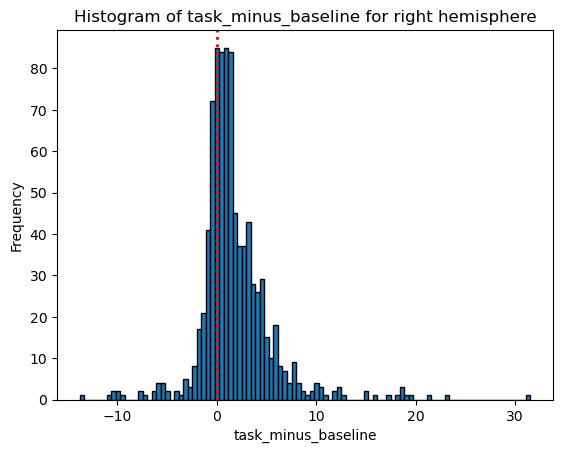

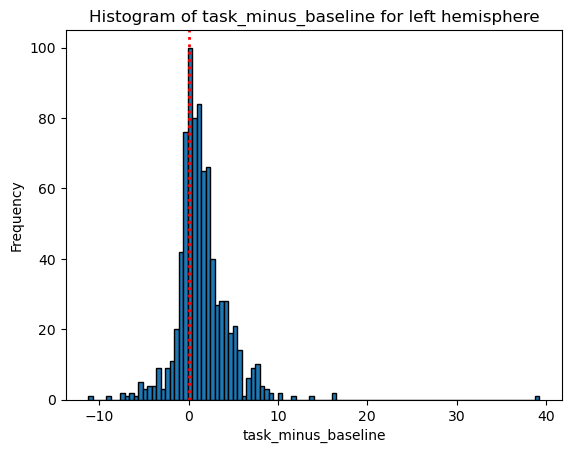

In [147]:
hemisphere_names = [
    "right",
    "left"
]
for i in range(len(hemisphere_masks)):
    hemisphere_mask = hemisphere_masks[i]
    hemisphere_name = hemisphere_names[i]
    col = "task_minus_baseline"
    df[hemisphere_mask][col].plot(kind='hist', bins=100, edgecolor='black')

    plt.axvline(x=0, color='red', linestyle=':', linewidth=2)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Histogram of {col} for {hemisphere_name} hemisphere')
    plt.show()

In [148]:
channel_responses = np.zeros(24)
for i in range(len(right_channels)):
    right_channel = right_channels[i]
    left_channel = left_channels[i]
    both_channels = [
        right_channel,
        left_channel
    ]
    both_mean_responses = []
    for channel in both_channels:
        channel_mask = df['channel'] == channel
        responses = df[oxy_mask & channel_mask]['task_minus_baseline']
        mean_response = np.mean(responses)
        both_mean_responses.append(mean_response)
        channel_responses[channel-1] = mean_response
    diff = both_mean_responses[1] - both_mean_responses[0]
    print(" ".join([str(x) for x in both_channels]), "|", " ".join(f"{x:.1f}" for x in both_mean_responses), "|", f"{diff:.1f}")
print()

channel_responses = np.array(channel_responses)
right = channel_responses[:12]
left = channel_responses[12:]
hemisphere_channel_responses = [
    right,
    left
]
for i in range(len(hemisphere_channel_responses)):
    hemisphere_channel_response = hemisphere_channel_responses[i]
    hemisphere_name = hemisphere_names[i]
    hemi_mean = np.mean(hemisphere_channel_response)
    hemi_std = np.std(hemisphere_channel_response)
    print(f"{hemisphere_name} hemisphere channel response")
    print('mean', f"{hemi_mean:.1f}")
    print('std', f"{hemi_std:.1f}")
    print()

1 14 | 2.1 2.4 | 0.2
2 13 | 3.0 3.3 | 0.3
3 17 | 2.6 2.8 | 0.1
4 16 | 2.7 1.7 | -1.0
5 15 | 2.8 0.6 | -2.2
6 19 | 2.7 2.6 | -0.0
7 18 | 2.7 2.3 | -0.4
8 22 | 2.6 2.6 | -0.0
9 21 | 3.3 2.0 | -1.3
10 20 | 3.7 3.0 | -0.7
11 24 | 2.4 2.2 | -0.2
12 23 | 2.8 1.7 | -1.2

right hemisphere channel response
mean 2.8
std 0.4

left hemisphere channel response
mean 2.3
std 0.7



### Hypothesis 2: In novices, orbital activity is more pronounced than lateral activity.

In [149]:
orbital_left_ch = [14, 17]
orbital_right_ch = [1, 3]
lateral_left_ch = [13, 15, 16, 18, 19, 21]
lateral_right_ch = [2, 4, 5, 6, 7, 9]
orbital_ch = orbital_left_ch + orbital_right_ch
lateral_ch = lateral_left_ch + lateral_right_ch
together = [
    orbital_ch,
    lateral_ch
]

together_masks = []
for area in together:
    area_masks = []
    for channel_num in area:
        area_masks.append(df['channel'] == channel_num)
    area_mask = functools.reduce(lambda x, y: x | y, area_masks)
    together_masks.append(area_mask)

together_mean_responses = [np.mean(df[oxy_mask & novice_mask & mask]['task_minus_baseline']) for mask in together_masks]
print(together_mean_responses)

[0.6766735714285715, 4.783159444444445]


### Hypothesis 3: Prefrontal hemodynamic response as monitored with fNIRS is sensitive to surgical expertise.

In [158]:
experience_mean_responses = [np.mean(df[oxy_mask & mask]['task_minus_baseline']) for mask in experience_masks]
print(experience_mean_responses)
print()

print("_ |", "    ".join(experience_letters), "| _")
all_diffs = np.zeros((len(all_channels), 2))
for i in all_channels:
    channel_mask = df['channel'] == i
    channel_experience_responses = []
    for j in range(len(experience_masks)):
        experience_mask = experience_masks[j]
        responses = df[oxy_mask & channel_mask & experience_mask]['task_minus_baseline']
        mean_response = np.mean(responses)
        channel_experience_responses.append(mean_response)
    amplitude = max(channel_experience_responses) - min(channel_experience_responses)
    diffs = np.diff(channel_experience_responses)
    all_diffs[i-1] = diffs
    print(i, "|", my_str(channel_experience_responses), "|", my_str(diffs), "|", f"{amplitude:.1f}")
print()
diff_means = np.mean(all_diffs, axis=0)
print(diff_means)

[2.531000357377049, 2.365181788770054, 2.9688877048192777]

_ | C    R    N | _
1 | 2.6 2.6 0.1 | 0.0 -2.5 | 2.5
2 | 1.3 2.5 8.4 | 1.3 5.8 | 7.1
3 | 3.8 2.5 1.4 | -1.3 -1.1 | 2.5
4 | 1.8 2.4 4.9 | 0.6 2.5 | 3.1
5 | 1.0 1.8 8.7 | 0.8 6.9 | 7.7
6 | 3.1 2.5 2.2 | -0.6 -0.3 | 0.9
7 | 3.1 1.8 4.0 | -1.3 2.3 | 2.3
8 | 2.9 2.5 2.6 | -0.4 0.1 | 0.4
9 | 3.6 2.9 3.7 | -0.8 0.8 | 0.8
10 | 2.6 1.9 8.8 | -0.7 6.9 | 6.9
11 | 3.3 2.2 1.1 | -1.1 -1.1 | 2.2
12 | 3.9 2.6 1.9 | -1.3 -0.7 | 2.0
13 | 1.9 0.8 18.3 | -1.1 17.5 | 17.5
14 | 2.6 3.1 -0.0 | 0.5 -3.2 | 3.2
15 | -0.4 -0.1 13.5 | 0.3 13.6 | 13.9
16 | 1.8 1.8 0.9 | -0.0 -0.9 | 0.9
17 | 3.5 3.0 1.3 | -0.6 -1.7 | 2.3
18 | 1.8 1.7 4.4 | -0.0 2.7 | 2.7
19 | 2.7 2.0 4.1 | -0.7 2.1 | 2.1
20 | 2.1 4.1 4.0 | 2.1 -0.2 | 2.1
21 | 2.2 2.4 0.9 | 0.2 -1.5 | 1.5
22 | 3.4 2.7 0.4 | -0.7 -2.3 | 3.0
23 | 1.6 3.1 -0.2 | 1.5 -3.3 | 3.3
24 | 2.8 2.4 0.8 | -0.4 -1.7 | 2.1

[-0.15882739  1.7018477 ]
